In [1]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

plt.rcdefaults()

# 2. Apply the local, lightweight sans-serif computer modern configurations
plt.rcParams.update({
    "text.usetex": False,                                 # Disable external LaTeX requirement
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "cmss10", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",                       # Safest built-in engine for sans-serif math
})

In [2]:
# advect a gaussian bump to show a first order upwind scheme has numerical mixing that acts as diffusion
def gaussian(x_array, mu = 0, sigma = 1):
    """
    Calculate Gaussian bump (initial condition)
    x_array = x-values
    mu = mean
    sigma = standard deviation
    """
    g = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_array - mu) / sigma)**2)

    return g

In [3]:
dx = 0.1
x_max = 20
x_min = - x_max
x_array = np.arange(x_min,x_max,dx)
g = gaussian(x_array)

In [4]:
# advection scheme
dt = 0.25
u = 0.25
dx = dx
max_time = 30
lambda_n = g
kappa = 1e-2

# check that there is no violation of the CFL condition 
# use a general CFL condition s.t. CFL # <= 1
CFL_adv = u * dt / dx
if CFL_adv > 1:
    print('CFL adv condition violated')

CFL_diff = kappa * dt / dx**2
if CFL_diff > 0.5:
    print('CFL diff condition violated')

# assign boundary conditions
lambda_n[-1] = 0
lambda_n[0] = 0

In [5]:
time_elapsed = 0
lambda_n = g

while time_elapsed < max_time:
    
    lambda_np1 = lambda_n.copy()

    # FOU advection scheme
    lambda_np1_adv = lambda_n.copy()
    lambda_np1_adv[1:] = ((-u * dt / dx) * (lambda_n[1:] - lambda_n[:-1]) ) + lambda_n[1:]

    # force the first and last boundaries to = 0
    lambda_np1_adv[0] = 0
    lambda_np1_adv[-1] = 0

    lambda_np1_diff = np.zeros_like(lambda_n)
    
    # central differencing for diffusion
    lambda_np1_diff[1:-1] = (kappa * dt / dx**2) * (lambda_n[2:] - 2*lambda_n[1:-1] + lambda_n[:-2])

    # update lambda
    lambda_np1 = lambda_np1_adv + lambda_np1_diff
    
    # force first and last boundaries to = 0
    # force the first and last boundaries to = 0
    lambda_np1[0] = 0
    lambda_np1[-1] = 0

    lambda_n = lambda_np1

    time_elapsed += dt

In [6]:
# run s.t. you only include the advection scheme
time_elapsed = 0
lambda_n_adv = g

while time_elapsed < max_time:
    
    lambda_np1_adv = lambda_n_adv.copy()

    # FOU advection scheme
    lambda_np1_adv = lambda_n.copy()
    lambda_np1_adv[1:] = ((-u * dt / dx) * (lambda_n_adv[1:] - lambda_n_adv[:-1]) ) + lambda_n_adv[1:]

    # force the first and last boundaries to = 0
    lambda_np1_adv[0] = 0
    lambda_np1_adv[-1] = 0
    
    # force first and last boundaries to = 0
    # force the first and last boundaries to = 0
    lambda_np1_adv[0] = 0
    lambda_np1_adv[-1] = 0

    lambda_n_adv = lambda_np1_adv

    time_elapsed += dt

lambda_n_adv_only = lambda_n_adv

/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmss10.
  func(*args, **kwargs)
/global/homes/k/kuyeda/.conda/envs/lanl_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmss10.
  fig.canvas.print_figure(bytes_io, **kw)


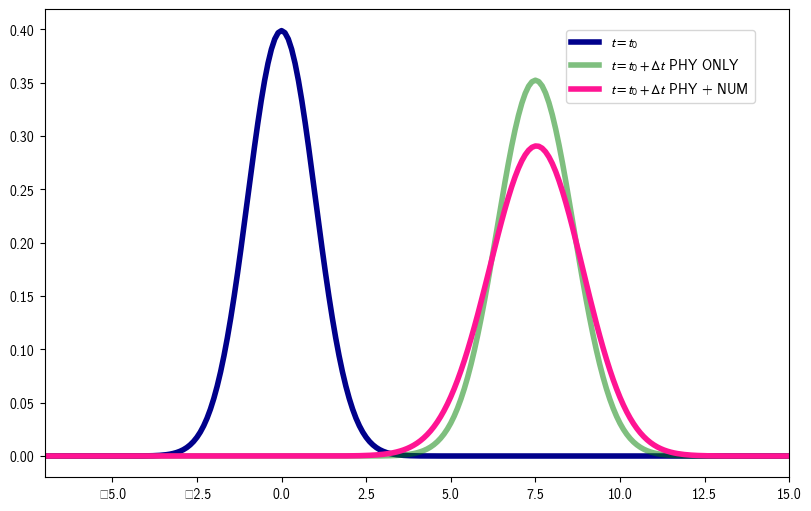

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols=1, constrained_layout=True, figsize=(8,5))
ax.plot(x_array, g, label = r'$t= t_0$', linewidth = 4, color='darkblue')
ax.plot(x_array, lambda_n_adv_only, label=r'$t=t_0 + \Delta t$ PHY ONLY', linewidth = 4, color = 'green', alpha = 0.5)
ax.plot(x_array, lambda_np1, label = r'$t = t_0 + \Delta t$ PHY + NUM', linewidth = 4, color = 'deeppink')#'cornflowerblue')#'lightsteelblue')
ax.set_xlim(-7,15)
ax.legend(loc=[0.7,0.8])

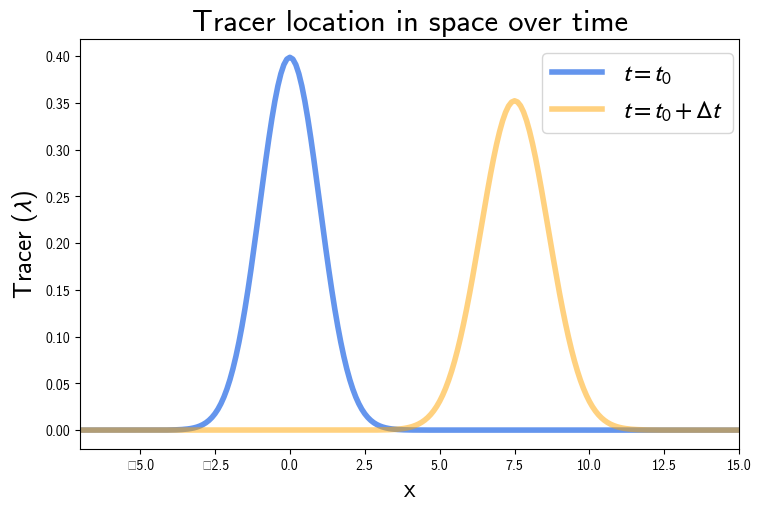

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols=1, constrained_layout=True, figsize=(7.5,5))
ax.plot(x_array, g, linewidth = 4, color='cornflowerblue', label=r'$t = t_0$')
ax.plot(x_array, lambda_n_adv_only, linewidth = 4, color = 'orange', alpha = 0.5, label=r'$t = t_0 + \Delta t$')
ax.set_xlim(-7,15)
ax.set_xlabel('x',fontsize=18)
ax.set_ylabel(r'Tracer ($\lambda$)',fontsize=18)
ax.set_title('Tracer location in space over time',fontsize=22)
ax.legend(loc=[0.7,0.77], fontsize=18)

Text(0.5, 1.0, 'Tracer distribution over time')

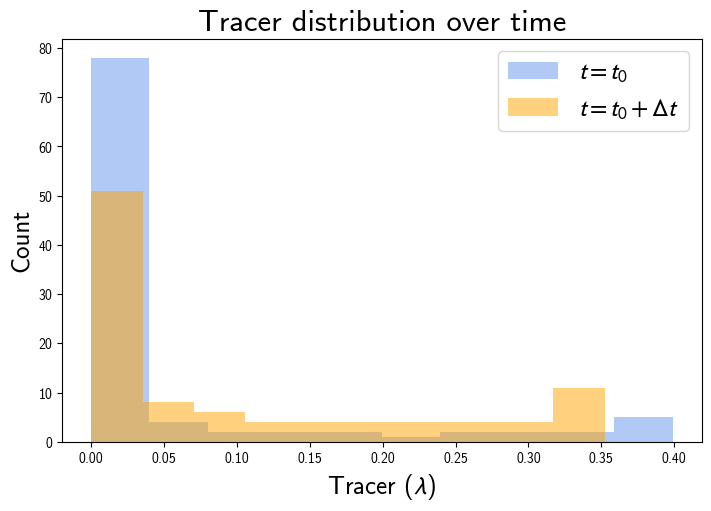

In [12]:
fig,ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True, figsize=(7,5))
ax.hist(g[200:300], bins=10, color = 'cornflowerblue', alpha=0.5, label=r'$t = t_0$');
ax.hist(lambda_n_adv_only[200:300],bins=10, color = 'orange', alpha=0.5, label = r'$t = t_0 + \Delta t$');
ax.legend(fontsize=18)
ax.set_xlabel(r'Tracer ($\lambda$)',fontsize=18)
ax.set_ylabel('Count',fontsize=18)
ax.set_title('Tracer distribution over time', fontsize=22)

In [108]:
x_array

array([-7.00000000e+00, -6.90000000e+00, -6.80000000e+00, -6.70000000e+00,
       -6.60000000e+00, -6.50000000e+00, -6.40000000e+00, -6.30000000e+00,
       -6.20000000e+00, -6.10000000e+00, -6.00000000e+00, -5.90000000e+00,
       -5.80000000e+00, -5.70000000e+00, -5.60000000e+00, -5.50000000e+00,
       -5.40000000e+00, -5.30000000e+00, -5.20000000e+00, -5.10000000e+00,
       -5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -